In [70]:
import pandas as pd
import numpy as np
import scipy
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats

In [71]:
import matplotlib.pyplot as plt

In [72]:
from scipy.stats import binom

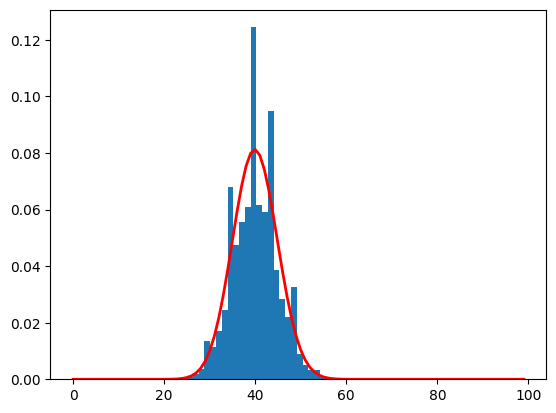

In [73]:
#Binomial
n, p, size = 100, 0.4, 10000
rng = np.random.default_rng()
sample = rng.binomial(n,p,size=size)
count, bins, _ = plt.hist(sample, 30, density=True)
x = np.arange(n)
y = binom.pmf(x,n,p)
plt.plot(x,y,linewidth=2,color='r')

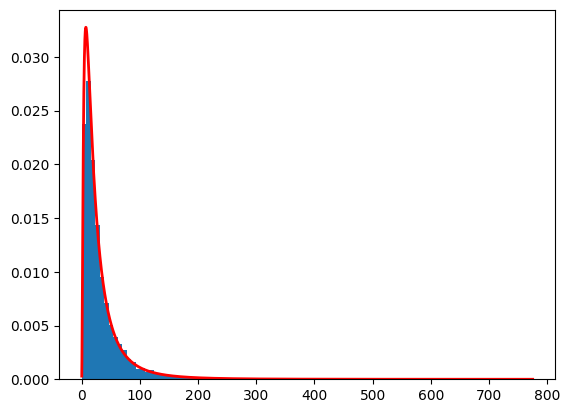

In [74]:
#lognormal
mu, sigma = 3. , 1. #mean and standard deviation
s = rng.lognormal(mu, sigma, 10000)
count, bins, _ = plt.hist(s,100,density=True,align='mid')
x = np.linspace(min(bins), max(bins), 10000)
pdf = (np.exp(-(np.log(x) - mu)**2 / (2 * sigma**2))/(x * sigma * np.sqrt(2 * np.pi)))
plt.plot(x, pdf, linewidth = 2, color = 'r')
plt.axis('tight')
plt.show()

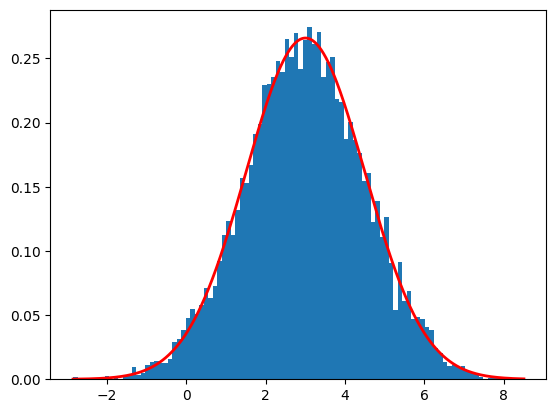

In [75]:
#normal
mu_n, sigma_n = 3, 1.5 #mean and standard deviation
n = rng.normal(mu_n, sigma_n, 10000)
count, bins, _ = plt.hist(n, 100, density=True, align='mid')
x_n = np.linspace(min(bins), max(bins), 10000)
pdf_n = (np.exp(-((x_n - mu_n)**2) / (2 * sigma_n**2))) / (sigma_n * np.sqrt(2 * np.pi))
plt.plot(x_n, pdf_n, linewidth=2, color='r')
plt.axis('tight')
plt.show()

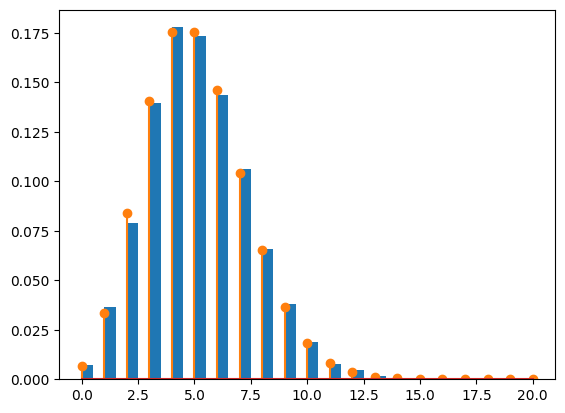

In [76]:
#poisson
lam, size = 5, 10000
p = rng.poisson(lam=lam, size=size)
x_p = np.arange(0,21)
pmf_p = stats.poisson.pmf(x_p, mu=lam)
plt.hist(p, bins = x_p, density=True, width=0.5)
plt.stem(x_p, pmf_p, 'C1-')
plt.show()

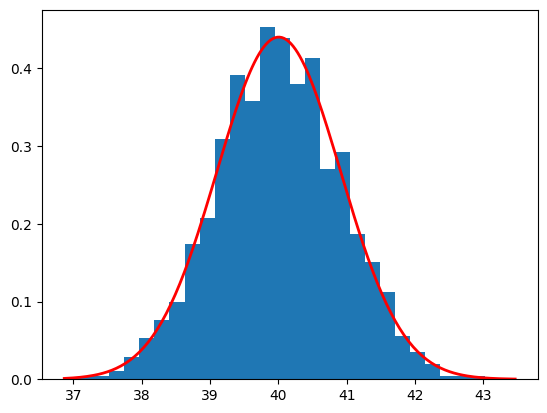

In [77]:
#Central Limit Theorem
n1, p1, size1 = 100, 0.4, (5000,30)
samples = rng.binomial(n1,p1,size=size1)
means = samples.mean(axis=1)
plt.hist(means, bins=30, density=True)
mu = means.mean()
sigma = means.std()
x = np.linspace(means.min(), means.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r', linewidth=2)
plt.show()

In [78]:
from scipy.stats import skew, kurtosis

In [79]:
end_date = datetime.today()
print(end_date)

2026-04-25 02:22:30.305176


In [80]:
start_date = end_date - timedelta(days=60)
print(start_date)

2026-02-24 02:22:30.305176


In [81]:
ticker = ['BZ=F']
df = yf.download(ticker, start = start_date, end = end_date, auto_adjust=False, actions=False)

[*********************100%***********************]  1 of 1 completed


In [82]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,,
2026-02-24,70.769997,70.769997,72.239998,70.709999,71.470001,37988
2026-02-25,70.849998,70.849998,71.760002,70.449997,71.220001,18491
2026-02-26,70.750000,70.750000,72.589996,69.320000,71.110001,17725
2026-02-27,72.480003,72.480003,72.989998,70.440002,70.500000,79435
2026-03-02,77.739998,77.739998,82.110001,75.790001,77.000000,143671


In [83]:
adj_close = df['Adj Close']
adj_close

Ticker,BZ=F
Date,
2026-02-24,70.769997
2026-02-25,70.849998
2026-02-26,70.750000
2026-02-27,72.480003
2026-03-02,77.739998
2026-03-03,81.400002
2026-03-04,81.400002
2026-03-05,85.410004
2026-03-06,92.690002


In [84]:
returns = adj_close.pct_change().dropna()
returns

Ticker,BZ=F
Date,
2026-02-25,0.001130
2026-02-26,-0.001411
2026-02-27,0.024452
2026-03-02,0.072572
2026-03-03,0.047080
2026-03-04,0.000000
2026-03-05,0.049263
2026-03-06,0.085236
2026-03-09,0.067645


Mean:  Ticker
BZ=F    0.009992
dtype: float64
Standard Deviation:  Ticker
BZ=F    0.057773
dtype: float64
Skewness:  [-1.18676442]
Kurtosis:  [0.82135536]


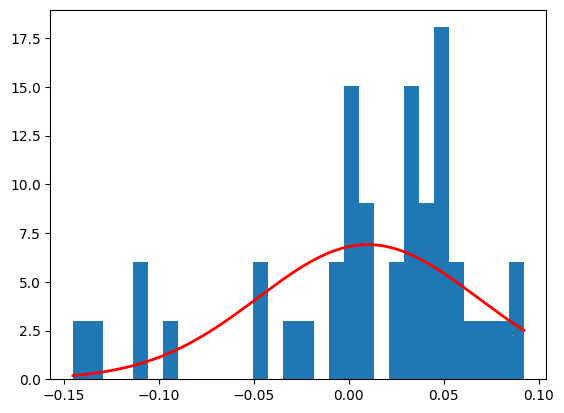

In [85]:
print('Mean: ', returns.mean())
print('Standard Deviation: ', returns.std())
print('Skewness: ', skew(returns))
print('Kurtosis: ', kurtosis(returns))
plt.hist(returns, bins=30, density=True)
mu = returns.mean()
sigma = returns.std()
x_r = np.linspace(returns.min(), returns.max(), 200)
plt.plot(x_r, stats.norm.pdf(x_r, mu, sigma), 'r', linewidth=2)
plt.show()